# Hull 6th chapter 14 PCA
https://www-2.rotman.utoronto.ca/~hull/calcs/RMFI6ecalcs.html

In [1]:
# !pip install xlrd

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# read interest rate history and convert to daily changes

In [2]:
fname = "Hull chapter 14 spreadsheets/PCA_6thEdition_Example.xls"
rates = pd.read_excel(fname, sheet_name='Daily data', index_col=0)
rates = rates.iloc[:,:8]
print(rates.shape)
rates[:3]

(2632, 8)


,1yr,2yr,3yr,5yr,7yr,10yr,20yr,30yr
2010-01-04,0.45,1.09,1.66,2.65,3.36,3.85,4.60,4.65
2010-01-05,0.41,1.01,1.57,2.56,3.28,3.77,4.54,4.59
2010-01-06,0.40,1.01,1.60,2.60,3.33,3.85,4.63,4.70


In [3]:
daily_change = rates.diff() * 100
daily_change[:3]

,1yr,2yr,3yr,5yr,7yr,10yr,20yr,30yr
2010-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-05,-4.0,-8.0,-9.0,-9.0,-8.0,-8.0,-6.0,-6.0
2010-01-06,-1.0,0.0,3.0,4.0,5.0,8.0,9.0,11.0


# compute covariance matrix

In [4]:
pd.DataFrame(covar := np.cov(daily_change[1:].transpose(),ddof=0))  # ddof = 0 for simple average (to match Hull)

,0,1,2,3,4,5,6,7
0,3.846316,3.939544,4.377546,4.656146,4.555959,4.188275,3.765120,3.547782
1,3.939544,9.795406,10.604258,12.129112,12.088504,11.062595,9.923489,9.190142
2,4.377546,10.604258,14.185780,16.429825,16.731267,15.459567,13.993370,12.987248
3,4.656146,12.129112,16.429825,21.774994,22.799075,21.602971,20.183929,18.935517
4,4.555959,12.088504,16.731267,22.799075,25.440400,24.516569,23.646917,22.458679
5,4.188275,11.062595,15.459567,21.602971,24.516569,24.984827,24.719754,23.799932
6,3.765120,9.923489,13.993370,20.183929,23.646917,24.719754,26.532106,25.733594
7,3.547782,9.190142,12.987248,18.935517,22.458679,23.799932,25.733594,25.965833


# compute eigenvalues and eigenvectors

In [5]:
eigenvalues, eigenvectors = np.linalg.eig(covar) 

# Sort eigenvalues and eigenvectors in descending order
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

print("Eigenvalues:")
display(pd.DataFrame(eigenvalues, index=[f"eigenvalue {i+1}" for i in range(8)]).transpose())
print("\nEigenvectors:")
display(pd.DataFrame(eigenvectors, columns=[f"eigenvector {i+1}" for i in range(8)]))
print("\nFactor Scores:")
display(pd.DataFrame(np.sqrt(eigenvalues), index=[f"FS {i+1}" for i in range(8)]).transpose())

Eigenvalues:


,eigenvalue 1,eigenvalue 2,eigenvalue 3,eigenvalue 4,eigenvalue 5,eigenvalue 6,eigenvalue 7,eigenvalue 8
0,133.225815,12.58074,3.155045,1.551598,0.820776,0.481414,0.389115,0.321158



Eigenvectors:


,eigenvector 1,eigenvector 2,eigenvector 3,eigenvector 4,eigenvector 5,eigenvector 6,eigenvector 7,eigenvector 8
0,0.082626,-0.241857,0.684755,0.681678,0.006066,0.024937,0.020666,0.004156
1,0.210423,-0.464884,0.376172,-0.573751,0.517449,0.030870,-0.011497,0.008445
2,0.285945,-0.466775,0.006199,-0.184589,-0.727697,-0.346549,-0.105685,0.073738
3,0.386277,-0.315024,-0.331865,0.144870,-0.060647,0.604366,0.347601,-0.361477
4,0.429581,-0.099154,-0.349419,0.264877,0.266395,0.007939,-0.263366,0.687738
5,0.427628,0.119292,-0.152695,0.171636,0.269301,-0.515302,-0.254381,-0.589373
6,0.426412,0.394100,0.172055,-0.098668,-0.026581,-0.243962,0.721867,0.205435
7,0.410716,0.478427,0.323141,-0.204230,-0.234081,0.433536,-0.460740,-0.035505



Factor Scores:


,FS 1,FS 2,FS 3,FS 4,FS 5,FS 6,FS 7,FS 8
0,11.542349,3.546934,1.776245,1.245632,0.905967,0.69384,0.623791,0.566708


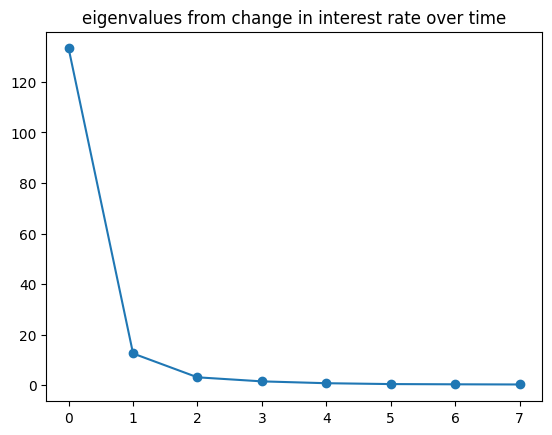

In [6]:
plt.plot(eigenvalues,'o-')
plt.title('eigenvalues from change in interest rate over time')
plt.show()

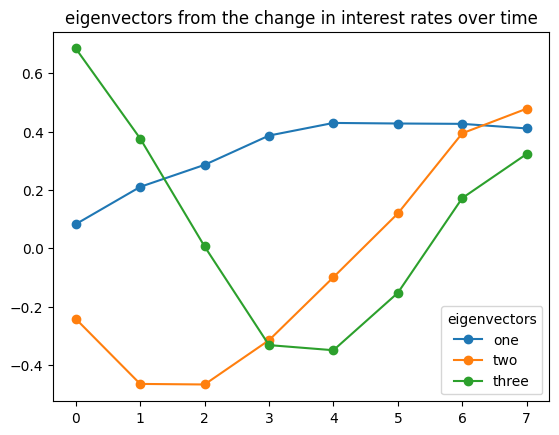

In [7]:
plt.plot(eigenvectors.T[:3].T, 'o-', label=['one','two','three'])
plt.legend(title="eigenvectors")
plt.title('eigenvectors from the change in interest rates over time')
plt.show()